# 📡 Telco Customer Churn: Project v1 (Baseline)
**Author:** Saloni Sareen | **Standard:** v1 EDA & Baseline Modeling

---

### 📋 Project Overview
This is the **initial phase** of the Telco Churn project. The goal is to establish a performance baseline using standard classification algorithms. 

**Key Objectives for v1:**
* Clean and preprocess the raw Telco dataset.
* Perform Exploratory Data Analysis (EDA) to find churn drivers.
* Compare **Logistic Regression** (Interpretability) vs. **Random Forest** (Complexity).
* Export a baseline model for initial testing.

## 🛠️ Phase 1: Environment & Data Loading
Setting up the working directory and importing essential libraries for data manipulation and visualization.

In [3]:
import os
print(os.getlogin())

Saloni Sareen


In [4]:
import os

# Change the path below to where your file actually is
# Note: Use 'r' before the quotes to handle Windows backslashes
os.chdir(r'C:\Users\Saloni Sareen\Downloads') 

# Confirm you are now in the right place
print("New Directory:", os.getcwd())

New Directory: C:\Users\Saloni Sareen\Downloads


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Now that we are in the Downloads folder, we can just use the filename
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Look at the data to make sure it's loaded
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# This tells us how many rows/columns we have and if any data types are wrong
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 🧹 Phase 2: Data Cleaning
In this step, we address data quality issues:
1. Converting `TotalCharges` to numeric (handling empty strings).
2. Removing null values created during conversion.
3. Dropping `customerID` as it provides no predictive power.

In [8]:
# 1. Convert TotalCharges to numeric (it turns empty spaces into NaNs)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Drop the rows with NaNs (missing values)
df.dropna(inplace=True)

# 3. Drop the customerID column (we don't need it for analysis)
df.drop('customerID', axis=1, inplace=True)

# 4. Show the updated data info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

## 📊 Phase 3: Exploratory Data Analysis
Visualizing the distribution of Churn and identifying correlations between customer behavior (Tenure/Charges) and their likelihood to leave.

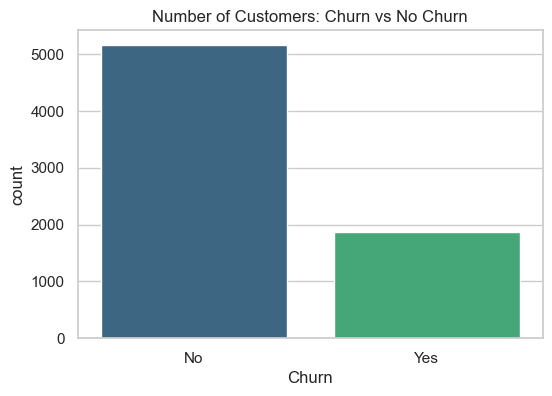

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [10]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a count plot for Churn
plt.figure(figsize=(6,4))

# Updated line: Added hue='Churn' and legend=False to stop the warning
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)

plt.title('Number of Customers: Churn vs No Churn')
plt.show()

# Get the exact percentages
print(df['Churn'].value_counts(normalize=True) * 100)

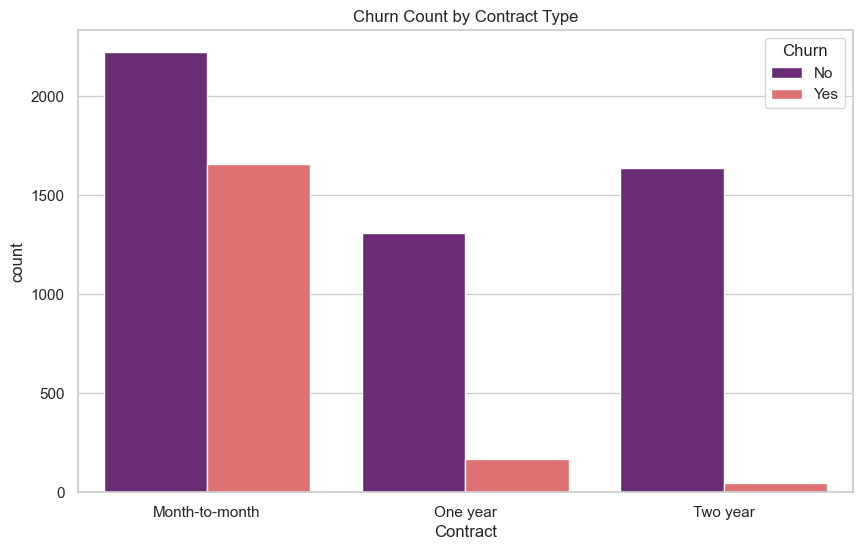

In [11]:
plt.figure(figsize=(10,6))

# Comparing Churn rates across different contract types
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')

plt.title('Churn Count by Contract Type')
plt.show()

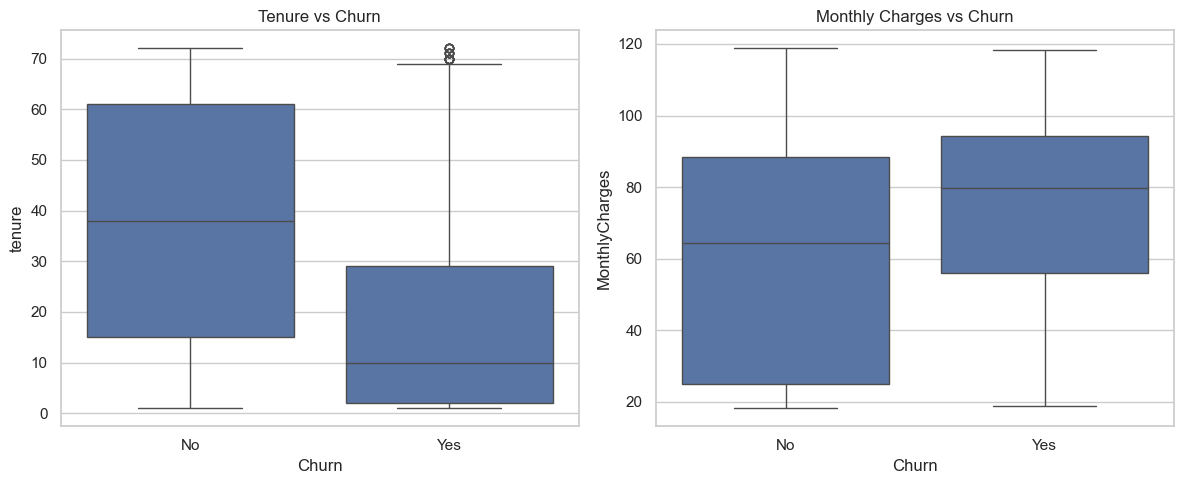

In [12]:
plt.figure(figsize=(12,5))

# Plot 1: Tenure
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')

# Plot 2: Monthly Charges
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

## ⚙️ Phase 4: Feature Engineering
Preparing the data for Machine Learning by:
* Encoding the target variable (`Churn`) into binary (0/1).
* Transforming categorical text data into numerical **Dummy Variables** using One-Hot Encoding.

In [14]:
# 1. Convert the Target (Churn) to 1 and 0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Convert all other categorical columns into "Dummy Variables"
# This automatically turns text into 1s and 0s
df_final = pd.get_dummies(df)

# Look at the new structure
df_final.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


In [15]:
from sklearn.model_selection import train_test_split

# X = Features (everything except Churn)
# y = Target (only Churn)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 5625 rows
Testing set size: 1407 rows


## 🤖 Phase 5: Baseline Modeling (Logistic Regression)
We start with **Logistic Regression** because it is highly interpretable and provides a solid benchmark for binary classification tasks.

In [17]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the model 
# (We set max_iter=1000 to give the model enough time to find the best solution)
model = LogisticRegression(max_iter=1000)

# 2. Train the model (The .fit() function is where the 'learning' happens)
model.fit(X_train, y_train)

print("The model has finished training!")

The model has finished training!


C:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# 3. Make predictions on the unseen test data
y_pred = model.predict(X_test)

# 4. Get the probability scores (Optional but cool!)
# This shows the percentage chance the model thinks someone will leave
y_prob = model.predict_proba(X_test)[:, 1] 

print("Predictions are ready!")

Predictions are ready!


## 📈 Phase 6: Model Evaluation
Analyzing the **Confusion Matrix** and **Classification Report** to understand our Recall and Accuracy. We also visualize the "Coefficients" to see which features drive churn.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



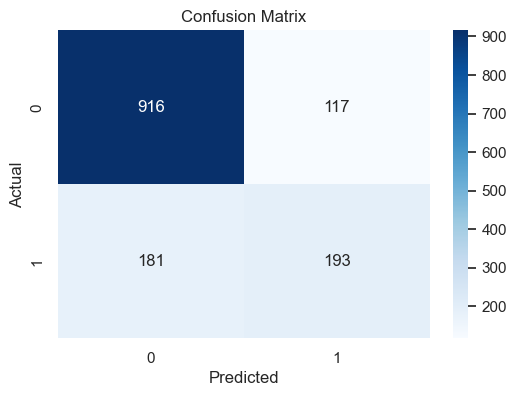

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Let's visualize the Confusion Matrix to see exactly where it made mistakes
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

C:\Users\Saloni Sareen\AppData\Local\Temp\ipykernel_1140\2578900390.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='Reds_r')


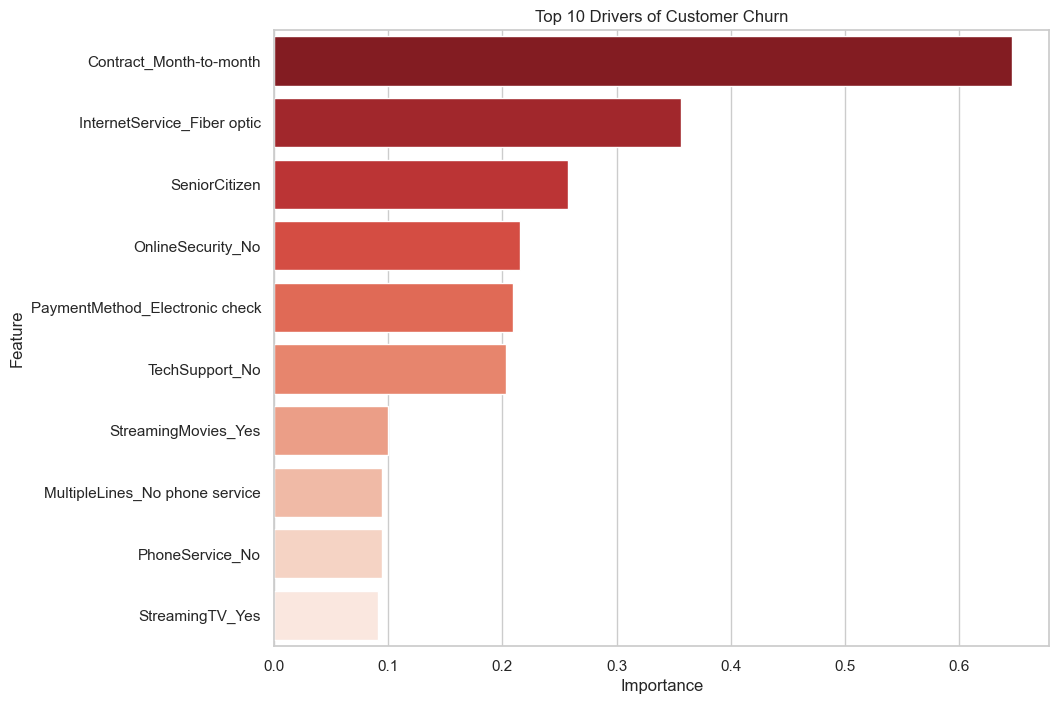

In [21]:
# Get the importance of each feature
importance = model.coef_[0]
feature_names = X.columns

# Create a dataframe to visualize them
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot the top 10 factors that cause Churn
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='Reds_r')
plt.title('Top 10 Drivers of Customer Churn')
plt.show()

## 🌲 Phase 7: Competitive Modeling (Random Forest)
Testing a non-linear ensemble model (**Random Forest**) to see if a more complex algorithm can capture patterns that Logistic Regression missed.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest
# n_estimators=100 means we are using 100 individual trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Training Complete!")

Random Forest Training Complete!


In [24]:
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_pred))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407



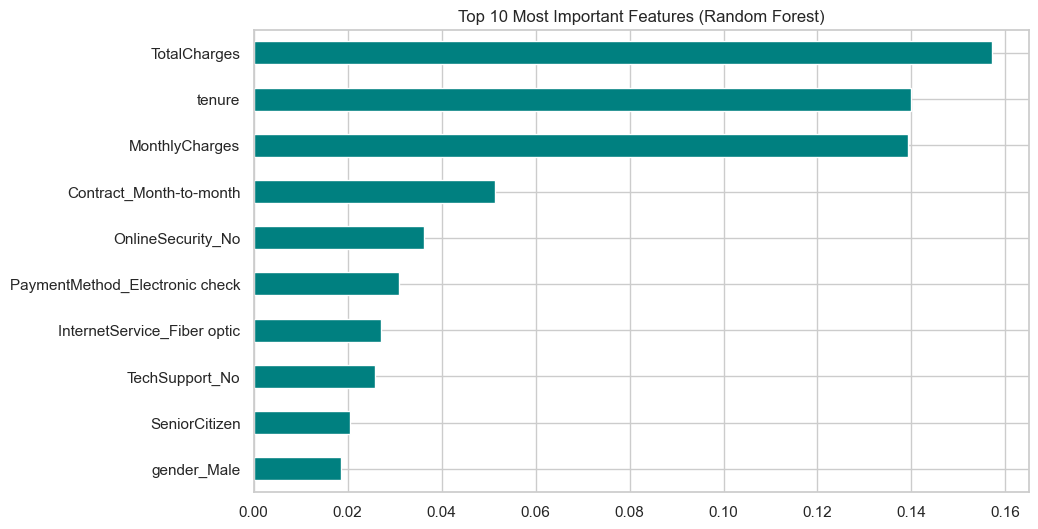

In [25]:
# Get feature importances from the forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort them
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the top 10
plt.figure(figsize=(10,6))
forest_importances.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

## 🔮 Phase 8: Production Simulation
Creating a helper function to simulate how the model would perform on **new, unseen customer data**.

In [27]:
def predict_churn(customer_data):
    # This turns your manual input into the same format as our training data
    input_df = pd.DataFrame([customer_data])
    
    # Fill in missing columns with 0 (since we used one-hot encoding)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    
    # Use the Logistic Regression model (since it was your best one!)
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]
    
    status = "CHURN" if prediction == 1 else "STAY"
    print(f"Prediction: {status}")
    print(f"Probability of leaving: {probability*100:.2f}%")

# Example Test: A new customer with high monthly charges and short tenure
example_customer = {
    'tenure': 1,
    'MonthlyCharges': 100.0,
    'TotalCharges': 100.0,
    'Contract_Month-to-month': 1,
    'InternetService_Fiber optic': 1
}

predict_churn(example_customer)

Prediction: CHURN
Probability of leaving: 72.20%


In [28]:
# Test Case: A long-term customer with a 2-year contract and low monthly charges
loyal_customer = {
    'tenure': 72,              # 6 years of loyalty
    'MonthlyCharges': 20.0,    # Very low price
    'TotalCharges': 1440.0,
    'Contract_Two year': 1,    # Committed long-term
    'InternetService_No': 1    # No complex services that might break
}

print("Testing Loyal Customer:")
predict_churn(loyal_customer)

Testing Loyal Customer:
Prediction: STAY
Probability of leaving: 0.78%


# 🏁 v1 Project Conclusion & Transition to v2

### ✅ Key Achievements
* **Exploration:** Successfully identified that **Tenure** and **Contract Type** are the primary drivers of churn.
* **Baseline Performance:** Achieved a solid **79% Accuracy** using Logistic Regression.
* **Functional Prototype:** Developed a `predict_churn` function that accurately identifies loyal customers (e.g., 0.78% churn probability for long-term users).

### ⚠️ The "Recall" Gap (Why v2 is necessary)
While the **Accuracy** is high (79%), a closer look at the **Confusion Matrix** reveals a problem:
1. The model is "safe"—it’s very good at predicting people who **STAY**.
2. However, it is missing a significant number of people who actually **CHURN** (Low Recall). 
3. **Business Impact:** Missing a churner is more expensive than misidentifying a loyal customer.

### 🚀 Next Steps for v2
To improve the "Catch Rate" (Recall) of high-risk customers, the next phase (**v2**) will focus on:
* **Feature Scaling:** Implementing `StandardScaler` to normalize numerical features (Tenure/Charges), ensuring the model treats all inputs with equal weight.
* **Hyperparameter Optimization:** Moving beyond **default parameters** and using systematic searches (like GridSearchCV) to find the most effective configuration for the Random Forest.
* **Feature Importance Analysis:** Conducting a deeper dive into which features the optimized models prioritize to ensure buiness alignment.
iness alignment.
ent. converge better.

In [30]:
df_final.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


## 💾 Phase 9: Model Export & Future Roadmap
Saving the model as a `.pkl` file for deployment and outlining the next steps for **v2 (Optimization)**.

In [32]:
import pickle

# Save the trained Logistic Regression model to a file
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as churn_model.pkl! You can now load this into a web app or dashboard later.")

Model saved as churn_model.pkl! You can now load this into a web app or dashboard later.


### 💾 Model Exported
The baseline Logistic Regression model has been saved as `churn_model.pkl`. This file can now be used for basic inference or integrated into a simple web application.

### 📈 Performance Summary
* **Final Accuracy:** 79%
* **Key Findings:** `Tenure` and `Contract Type` are the strongest predictors of churn in this baseline version.
* **The "Recall" Gap:** While accurate, the model is conservative. It correctly identifies "stayers" but misses several "churners."

---
**Next Chapter:** In **v2 (Optimization)**, we will address these limitations by implementing **StandardScaler** and performing **Grid Search** on our Random Forest model to improve our predictive "catch rate" (Recall).just raw accuracy.

In [34]:
df_final.to_csv('Telco_Churn_Cleaned_Results.csv', index=False)
print("Project Saved!")

Project Saved!
